In [324]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from collections import Counter
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
!pip install mlxtend


  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


In [268]:
df = pd.read_csv('Target.csv')

###  Data Cleaning and Preparation

#### Remove Duplicates

In [269]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")


Number of duplicate rows found: 0


#### Checking for Inconsistencies in 'Gender' Column

In [270]:
print(df['Gender'].value_counts())

Gender
Male                 214
Female               201
Others               196
Prefer not to say    189
Name: count, dtype: int64


##### Drop the first 'Personalized_Recommendation_Frequency' column
* Dropped the Personalized_Recommendation_Frequency column because it was a less informative (Yes/No) duplicate of the more detailed numerical Personalized_Recommendation_Rating column.

In [271]:
print(df.columns.tolist())

['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [272]:
df.drop(columns=['Personalized_Recommendation_Frequency'], inplace=True)

In [273]:
print(df.columns.tolist())

['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [274]:
# This targets the column with the trailing space and gives it a clean name
df.rename(columns={'Personalized_Recommendation_Frequency ': 'Personalized_Recommendation_Frequency'}, inplace=True)
df.rename(columns={'Rating_Accuracy ': 'Rating_Accuracy'}, inplace=True)

Removed the trailing spaces from column name

#### Handle Missing Values in 'Product_Search_Method'

In [275]:
missing_before = df['Product_Search_Method'].isnull().sum()
print(f"Missing values in 'Product_Search_Method' before filling: {missing_before}")

Missing values in 'Product_Search_Method' before filling: 180


In [325]:
if missing_before > 0:
    # Find the most frequent value (mode)
    mode_value = df['Product_Search_Method'].mode()
    # Fill missing values with the mode
    df['Product_Search_Method'].fillna(mode_value, inplace=True)
print(f"Missing values filled with mode: '{mode_value}'")


Missing values filled with mode: '0    Keyword
Name: Product_Search_Method, dtype: object'


Missing values filled with mode: Keyword

In [277]:
missing_after = df['Product_Search_Method'].isnull().sum()
print(f"Missing values in 'Product_Search_Method' after filling: {missing_after}")


Missing values in 'Product_Search_Method' after filling: 180


#####  Handle Inconsistent Formats with Complete Mappings

In [278]:
print("Unique values in 'Purchase_Frequency':", df['Purchase_Frequency'].unique())
print("Unique values in 'Cart_Completion_Frequency':", df['Cart_Completion_Frequency'].unique())

Unique values in 'Purchase_Frequency': ['Once a month' 'Multiple times a week' 'Few times a month'
 'Less than once a month' 'Once a week']
Unique values in 'Cart_Completion_Frequency': ['Rarely' 'Always' 'Sometimes' 'Often' 'Never']


##### Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis.

In [279]:
df[[
    'Customer_Reviews_Importance',
    'Personalized_Recommendation_Frequency',
    'Rating_Accuracy',
    'Shopping_Satisfaction'
]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Customer_Reviews_Importance            800 non-null    int64
 1   Personalized_Recommendation_Frequency  800 non-null    int64
 2   Rating_Accuracy                        800 non-null    int64
 3   Shopping_Satisfaction                  800 non-null    int64
dtypes: int64(4)
memory usage: 25.1 KB


##### All columns are already formatted correctly

###  Descriptive Behavior Analysis

#### Customer Demographics Summary

####  Summarize Age

In [280]:
print(df['age'].describe())

count    800.000000
mean      34.737500
std       18.938306
min        3.000000
25%       18.000000
50%       34.000000
75%       50.250000
max       67.000000
Name: age, dtype: float64


* Average Age: The average age of your customers is approximately 35 years old.
* Age Range: The ages range from a minimum of 3 to a maximum of 67 years old.
* Median Age: The median age is 34, which is very close to the average, suggesting a fairly symmetrical age distribution without extreme outliers pulling the average in one direction.

#### Summarize Gender Distribution

In [281]:
# Get the raw counts for each gender category
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
Male                 214
Female               201
Others               196
Prefer not to say    189
Name: count, dtype: int64


This tells us that no single gender group dominates your user base, it is very evenly split among all categories.

#### Overall Purchase Frequency

In [282]:
# Get raw counts
purchase_counts = df['Purchase_Frequency'].value_counts()
print(purchase_counts)

Purchase_Frequency
Multiple times a week     173
Less than once a month    168
Once a month              164
Few times a month         153
Once a week               142
Name: count, dtype: int64


The shopping frequency is quite evenly distributed across all segments, with no single group overwhelmingly dominating.

#### Most popular product categories. 

In [283]:
# 2. Create a empty list of all category mentions
all_mentions = []
# Loop through every row in the Purchase_Categories column
for response in df['Purchase_Categories']:
# Split the response into a list of individual categories using the semicolon
    categories = response.split(';')    
# For each individual category, add it to our empty list
    for item in categories:
# Strip any extra spaces to keep the names clean
        all_mentions.append(item)
# 4. Count the occurrences of each item in our master list
category_counts = Counter(all_mentions)

In [284]:
category_counts

Counter({'Beauty and Personal Care': 426,
         'Clothing and Fashion': 424,
         'Home and Kitchen': 406,
         'Groceries and Gourmet Food': 403,
         'others': 384})

* Beauty and Personal Care: 426 
* Clothing and Fashionv: 424
* Home and Kitchen: 406
* Groceries and Gourmet Food: 403
* others: 384



#### Identify top browsing methods 

In [285]:
search_methods = df['Product_Search_Method'].value_counts()
print(search_methods)

Product_Search_Method
Keyword       173
others        158
Filter        157
categories    132
Name: count, dtype: int64


##### A high count for "Keywords" suggests users know exactly what they want
Note:- The frequency of 'Keywords' stands at a high of 353, though it's important to note the pre-imputation count was 173, the increase is due to filling 180 missing values using the most frequent browsing method.

#### Identify Most Common Cart Abandonment Factors

In [286]:
abandonment_reasons_list = []
for response in df['Cart_Abandonment_Factors']:
    # Split the response by semicolon
    reasons = str(response).split(';')
    for reason in reasons:
        abandonment_reasons_list.append(reason)
# Count of each reason
abandonment_counts = Counter(abandonment_reasons_list)

In [287]:
abandonment_counts

Counter({'High shipping costs': 216,
         'others': 203,
         'Changed my mind or no longer need the item': 191,
         'Found a better price elsewhere': 190})

High shipping costs emerged as the primary reason for cart abandonment, indicating that delivery fees are the most significant barrier preventing customers from completing their purchases.

####  Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy. 

Calculating the mean (average) and median (the middle value) for these metrics allows us to gauge the overall success of the platform's features:
* Shopping Satisfaction: Tells us how happy customers are with their overall experience.
* Recommendation Helpfulness: Measures if the personalized suggestions are actually relevant to the users.
* Rating Accuracy: Indicates the trust in product ratings on the site match the customers' actual experiences.

#### Important Note:
While Shopping_Satisfaction and Rating_Accuracy are already numbers (1-5), Recommendation_Helpfulness is stored as text ("Yes", "Sometimes", "No"). To calculate a mean or median, we first need to convert these into a numerical scale (e.g., No=0, Sometimes=1, Yes=2).

In [288]:
# Numerical Mapping for Recommendation_Helpfulness . Map text to numbers: No=0, Sometimes=1, Yes=2
helpfulness_map = {'No': 0, 'Sometimes': 1, 'Yes': 2}
df['Recommendation_Helpfulness_Numeric'] = df['Recommendation_Helpfulness'].map(helpfulness_map)

In [289]:
# Calculate Mean and Median 
# Select only the columns we need for the calculation
target_cols = ['Shopping_Satisfaction', 'Recommendation_Helpfulness_Numeric', 'Rating_Accuracy']

# Apply .agg() and then .T (transpose) to flip the table for better readability
summary_stats = df[target_cols].agg(['mean', 'median']).T

# Rename the index for a cleaner look
summary_stats.index = ['Shopping Satisfaction', 'Recommendation Helpfulness', 'Rating Accuracy']

print(summary_stats.round(2))


                            mean  median
Shopping Satisfaction       2.94     3.0
Recommendation Helpfulness  1.00     1.0
Rating Accuracy             3.06     3.0


Since your Mean and Median are almost exactly the same, we can say our data is very balanced and has no extreme outliers. This means most customers share a similar 'average' opinion, and the data follows a normal, bell-shaped pattern.

#### Summary Statistics for Key Behavioral Variables

In [290]:
# Define the key numerical behavioral columns
behavioral_num_cols = [
    'Customer_Reviews_Importance', 
    'Shopping_Satisfaction', 
    'Rating_Accuracy'
]

In [291]:
#Generating Summary Statistics
summary_stats = df[behavioral_num_cols].describe().round(2)
display(summary_stats)

,Customer_Reviews_Importance,Shopping_Satisfaction,Rating_Accuracy
count,800.00,800.00,800.00
mean,3.00,2.94,3.06
std,1.43,1.44,1.44
min,1.00,1.00,1.00
25%,2.00,2.00,2.00
50%,3.00,3.00,3.00
75%,4.00,4.00,4.00
max,5.00,5.00,5.00


The standard deviations (around ~1.44) and the quartiles (25% at 2.0, 75% at 4.0) suggest that the ratings are actually spread very uniformly. While the average is right in the middle (3.0), customers are very evenly divided across all possible rating levels from 1 to 5.

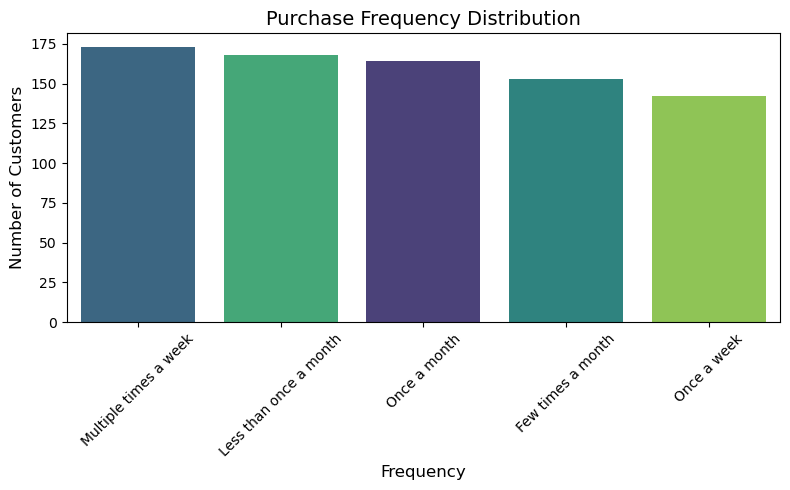

In [292]:
# Purchase Frequency (Bar Chart) 
plt.figure(figsize=(8, 5)) 
sns.countplot(
    data=df, 
    x='Purchase_Frequency',
    hue='Purchase_Frequency',
    palette='viridis',
    order=df['Purchase_Frequency'].value_counts().index,
    legend=False
)
plt.title('Purchase Frequency Distribution', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45) # Rotate text labels 
plt.tight_layout()
plt.show() # Display Plot 

The bar chart shows an incredibly flat distribution.There is no single dominant purchasing group, indicating a highly diverse user base.

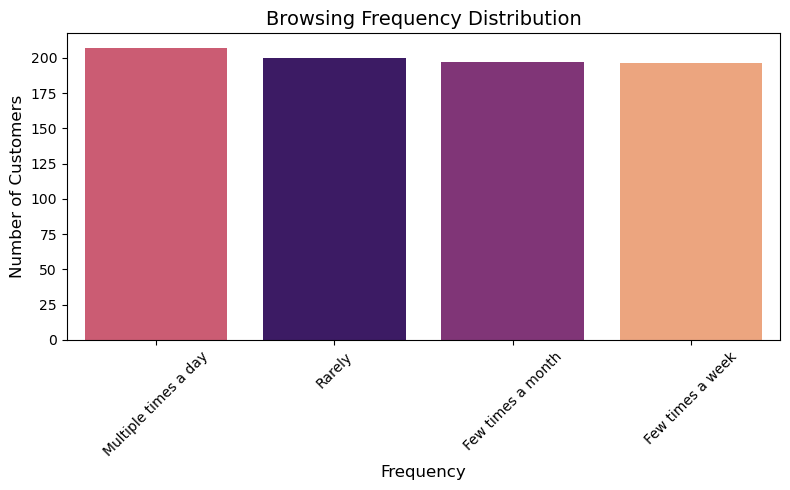

In [293]:
# Plot 2: Browsing Frequency (Bar Chart) 
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='Browsing_Frequency', 
    hue='Browsing_Frequency', # FIX: Assign x variable to hue
    palette='magma',
    order=df['Browsing_Frequency'].value_counts().index,
    legend=False
)
plt.title('Browsing Frequency Distribution', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() # Display Plot 

 Similar to purchasing, the browsing habits are almost perfectly balanced. 

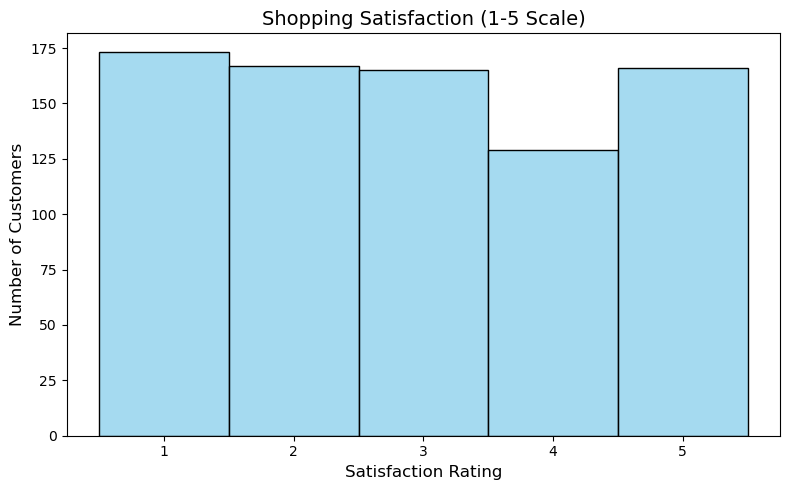

In [294]:
# Shopping Satisfaction (Histogram) 
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, 
    x='Shopping_Satisfaction', 
    bins=5, 
    discrete=True, 
    color='skyblue'
)
plt.title('Shopping Satisfaction (1-5 Scale)', fontsize=14)
plt.xlabel('Satisfaction Rating', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks([1, 2, 3, 4, 5]) # Ensure only whole numbers 1-5 are shown on x-axis
plt.tight_layout()
plt.show() # Display Plot 3

Customer satisfaction is relatively evenly spread across ratings 1, 2, 3, and 5, but there is a noticeable dip at a rating of 4, showing fewer users are 'moderately highly' satisfied.

### Customer Segmentation and Profiling

#### Segment Customers: Purchase Frequency vs. Shopping Satisfaction

In [295]:
# This calculates the average satisfaction score for each buying group
avg_sat_by_freq = df.groupby('Purchase_Frequency')['Shopping_Satisfaction'].mean().reset_index()
display(avg_sat_by_freq)

,Purchase_Frequency,Shopping_Satisfaction
0,Few times a month,2.875817
1,Less than once a month,2.964286
2,Multiple times a week,2.901734
3,Once a month,3.024390
4,Once a week,2.901408


Customer satisfaction remains consistent across all groups, with "Once a month" shoppers reporting the highest average satisfaction (3.02) while other frequencies hover closely around 2.9.


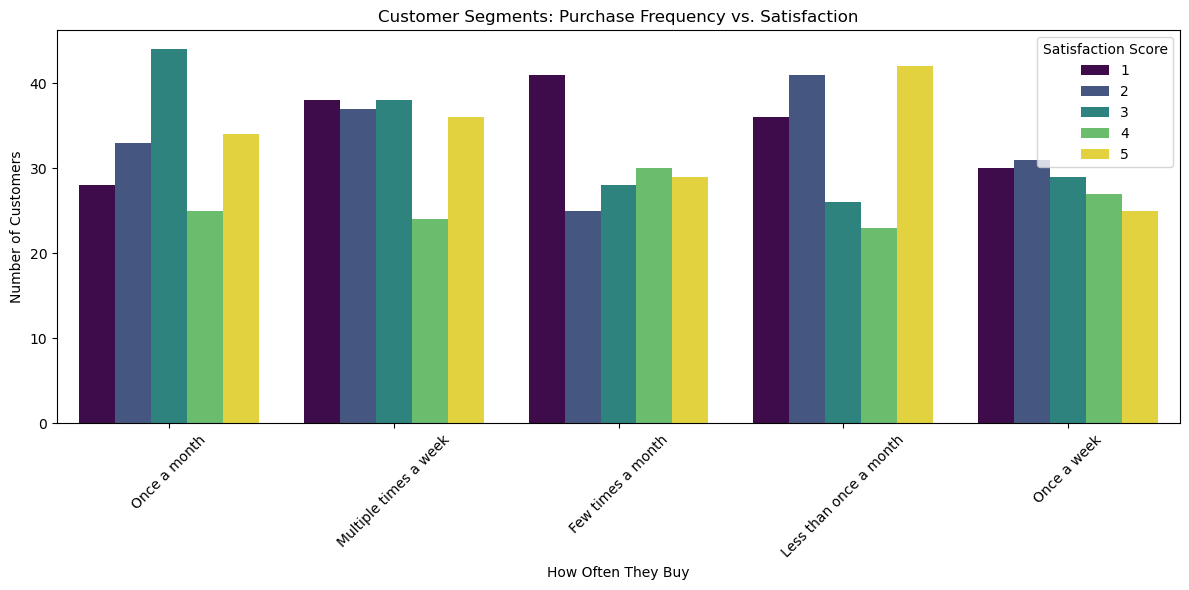

In [296]:
# Grouped Bar Chart 
# This creates a set of bars for each purchase frequency, split by satisfaction scores
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df, 
    x='Purchase_Frequency', 
    hue='Shopping_Satisfaction',
    palette='viridis'
)

plt.title('Customer Segments: Purchase Frequency vs. Satisfaction')
plt.xlabel('How Often They Buy')
plt.ylabel('Number of Customers')

plt.legend(
    title='Satisfaction Score', 
    loc='upper right'
)
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

Across all purchase frequencies, customer satisfaction is relatively evenly distributed, though "Less than once a month" shoppers show the highest peak in top-tier with satisfaction Score 5. Conversely, "Few times a month" shoppers exhibit a noticeable concentration of the lowest satisfaction score 1.


#### Create Customer Profiles
* Frequent Buyers: Customers who shop often (at least once a week) AND give high satisfaction ratings (4 or 5).
* At-Risk Customers: Customers who give low satisfaction ratings (1 or 2) OR rarely complete their purchases (frequently abandon their carts).
* Occasional Shoppers: Everyone else who falls in the middle (average shopping frequency and moderate satisfaction).

Customer_Profile
At-Risk Customers      492
Occasional Shoppers    196
Frequent Buyers        112
Name: count, dtype: int64


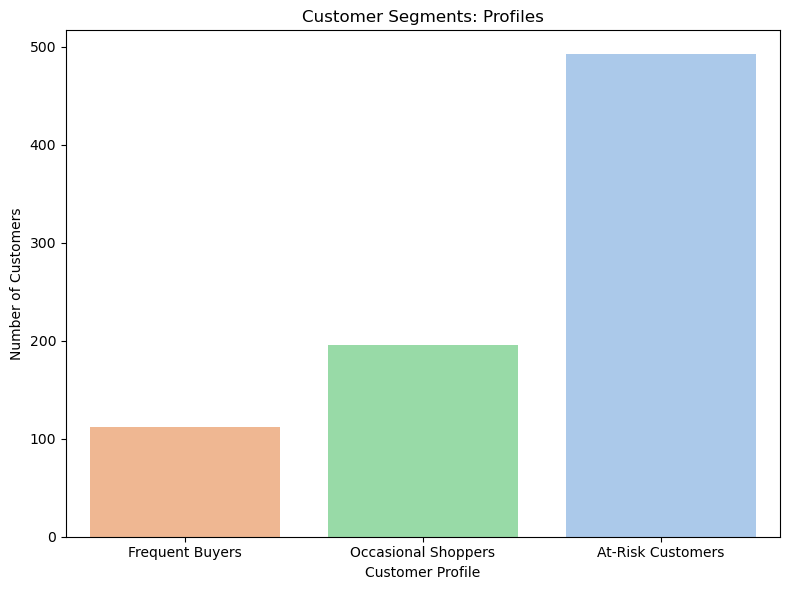

In [297]:
# 1. Define what counts as "High" purchase frequency
def create_profile(x):
    # 1. Define high frequency
    high_freq = ['Multiple times a day', 'Multiple times a week', 'Once a week']
    
    # 2. Rule for Frequent Buyers
    if (x['Purchase_Frequency'] in high_freq) and (x['Shopping_Satisfaction'] >= 4):
        return 'Frequent Buyers'
        
    # 3. Rule for At-Risk Customers
    elif (x['Shopping_Satisfaction'] <= 2) or (x['Cart_Completion_Frequency'] in ['Rarely', 'Never']):
        return 'At-Risk Customers'
        
    # 4. Default for everyone else
    else:
        return 'Occasional Shoppers'

# Apply this function to every row in our dataset
df['Customer_Profile'] = df.apply(create_profile, axis=1)

print(df['Customer_Profile'].value_counts())

# 5. Simple Bar Chart to see the sizes of each group
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df, 
    x='Customer_Profile', 
    hue='Customer_Profile',
    palette='pastel',
    legend = False,
    order=['Frequent Buyers', 'Occasional Shoppers', 'At-Risk Customers'] # Keeps bars in logical order
)

plt.title('Customer Segments: Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


A concerning majority of the user base 492 users falls into the "At-Risk Customers" category, highlighting severe issues with satisfaction and cart abandonment, while the business struggles to convert "Occasional Shoppers" 196 customers into a Frequent Buyer , highly loyal group of "Frequent Buyers" is just 112 customers.

#### Analyze demographic across these segments. 

In [298]:
#Demographic Differences Across Segments
# Average Age by Profile
age_by_profile = df.groupby('Customer_Profile')['age'].mean().reset_index()
print(age_by_profile)

      Customer_Profile        age
0    At-Risk Customers  34.457317
1      Frequent Buyers  35.892857
2  Occasional Shoppers  34.780612


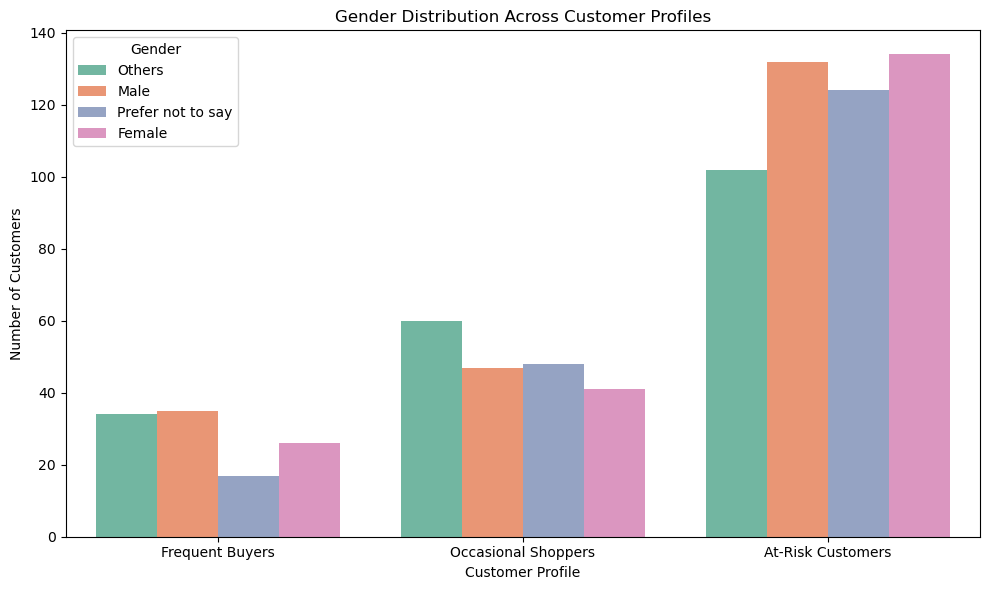

In [299]:
#Gender Distribution by Profile
# A grouped bar chart to see how genders are split across the profiles
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='Customer_Profile', 
    hue='Gender', 
    palette='Set2',
    order=['Frequent Buyers', 'Occasional Shoppers', 'At-Risk Customers']
)

plt.title('Gender Distribution Across Customer Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')

# Fix legend placement so it doesn't cover the bars
plt.legend(title='Gender', loc='upper left')
plt.tight_layout()
plt.show()

#### Analyze Behavioral Differences Across The Segments

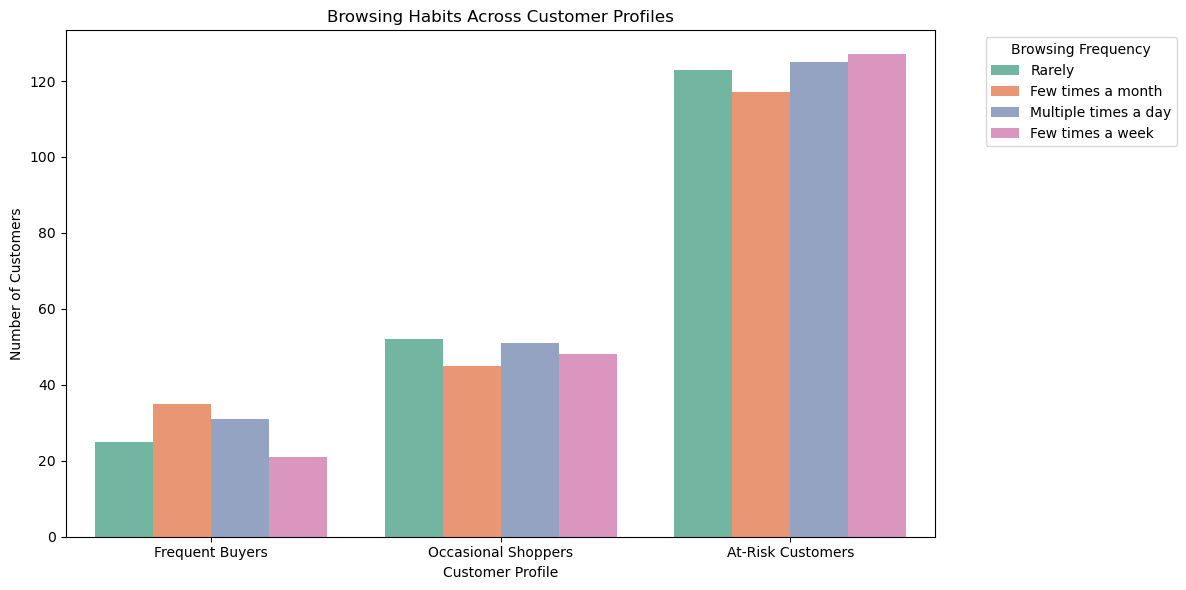

In [300]:
# Visualize Browsing Frequency by Profile

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='Customer_Profile',
    hue='Browsing_Frequency',
    palette='Set2',
    order=['Frequent Buyers', 'Occasional Shoppers', 'At-Risk Customers'] # Keep a logical order
)

plt.title('Browsing Habits Across Customer Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Number of Customers')
plt.legend(title='Browsing Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


At-Risk Customers represent the largest segment and browse most frequently, primarily multiple times a day or a few times a week. In contrast, Frequent Buyers have the lowest overall volume and tend to browse less often, with "Few times a month" being their most common habit.

### Hierarchical Clustering for Behavioral Grouping

In [301]:
# Define the behavioral columns related to shopping habits
habit_features = [
    'Browsing_Frequency',
    'Purchase_Frequency',
    'Cart_Completion_Frequency',
    'Saveforlater_Frequency'
]
df_habits = df[habit_features].copy()
# Use One-Hot Encoding because all these features are categorical text 
encoder = OneHotEncoder(sparse_output=False)
x_habits = encoder.fit_transform(df_habits[habit_features])


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

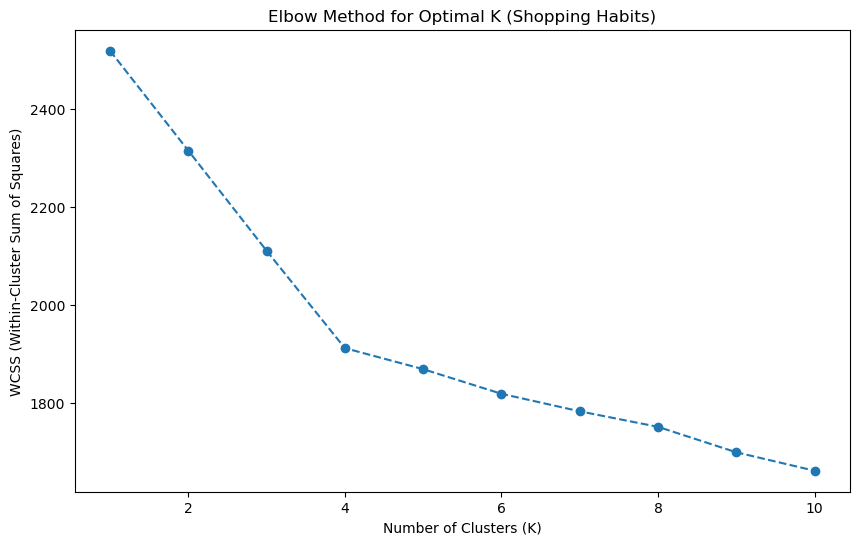

In [302]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x_habits)
    wcss.append(kmeans.inertia_)

# --- Plotting the Elbow Chart ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Shopping Habits)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')

plt.show()

In [347]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(x_habits)
df['KMeans_Cluster'] = kmeans_clusters


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


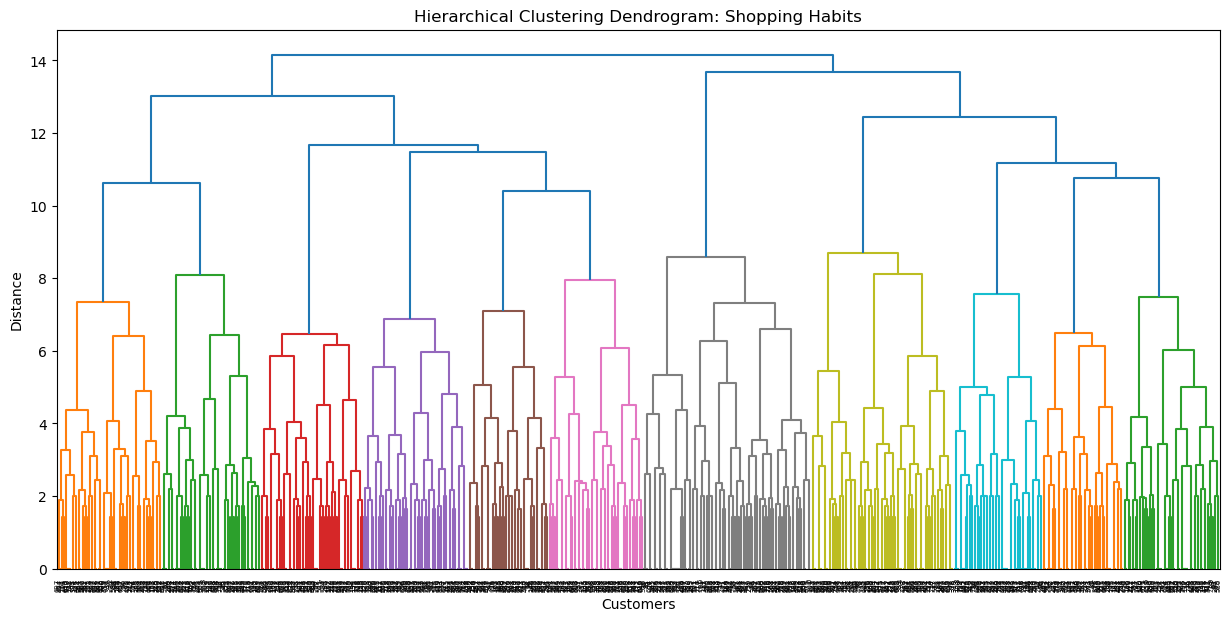

In [348]:
# Plot the dendrogram to visually determine optimal K
plt.figure(figsize=(15, 7))
linkage_matrix = linkage(x_habits, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram: Shopping Habits')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [349]:
hc_habits = AgglomerativeClustering(n_clusters=optimal_k)

df_habits['Habit_Cluster'] = hc_habits.fit_predict(x_habits)

display(df_habits['Habit_Cluster'].value_counts())

Habit_Cluster
0    281
1    263
3    140
2    116
Name: count, dtype: int64

In [350]:
# Evaluate Hierarchical Clustering with Silhouette Score
hierarchical_silhouette = silhouette_score(x_habits, df_habits['Habit_Cluster'])
print(f'Hierarchical Clustering Silhouette Score: {hierarchical_silhouette:.4f}')

Hierarchical Clustering Silhouette Score: 0.0402


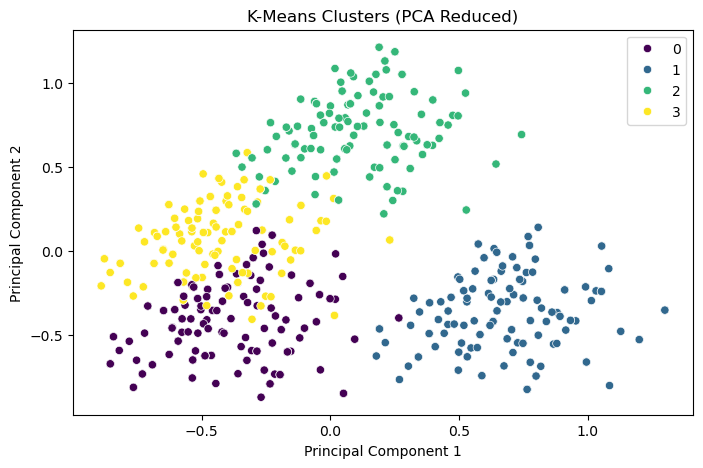

In [351]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_habits)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = kmeans_clusters

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis')
plt.title('K-Means Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


## Recommendation and Review Insights 


Examine Relationship: Recommendation Helpfulness vs. Shopping Satisfaction

In [308]:
# This groups users by their 'Recommendation_Helpfulness' score and calculates their average 'Shopping_Satisfaction'.
avg_satisfaction = df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean().reset_index()

In [309]:
display(avg_satisfaction)

,Recommendation_Helpfulness,Shopping_Satisfaction
0,No,2.875472
1,Sometimes,2.977778
2,Yes,2.950943


Helpful recommendations do not change how satisfied customers are, because the average satisfaction score stays the same (around 2.95) for everyone.

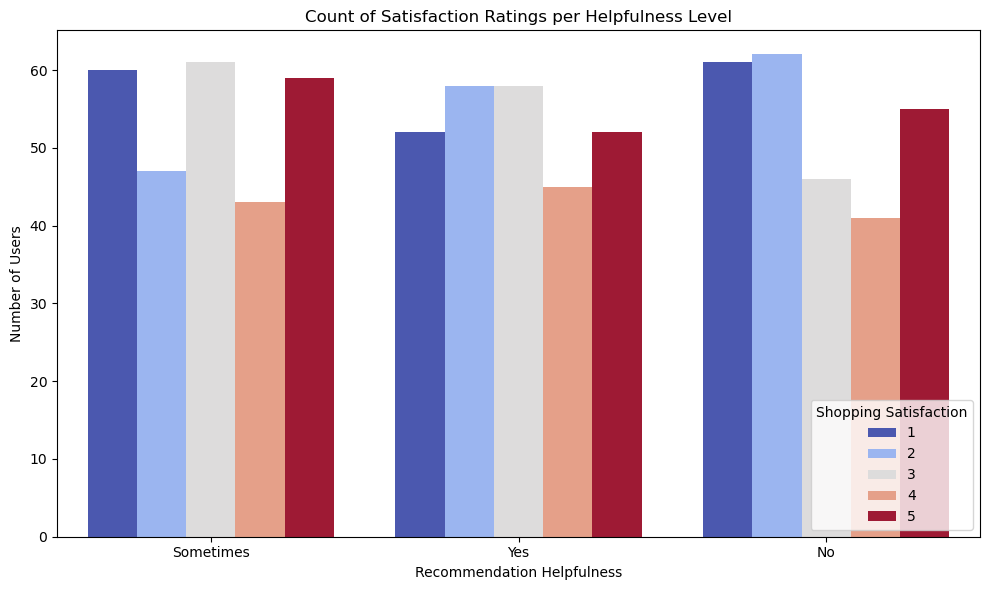

In [310]:
#Grouped Bar Chart (Visualizing Counts)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='Recommendation_Helpfulness', 
    hue='Shopping_Satisfaction',
    palette='coolwarm'
)
plt.title('Count of Satisfaction Ratings per Helpfulness Level')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Number of Users')
plt.legend(title='Shopping Satisfaction',  loc='lower right')
plt.tight_layout() 
plt.show()

Recommendation helpfulness has almost no impact on overall shopping satisfaction ,Even though the bar chart shows clear ups and downs,he overall average satisfaction stays the same (around 2.95) whether the recommendations were helpful or not.

#### Evaluate how review reliability and helpfulness impact overall ratings. 

In [311]:
# Investigate the unique values in the target columns
print("Review_Reliability values:", df['Review_Reliability'].unique())
print("Review_Helpfulness values:", df['Review_Helpfulness'].unique())

Review_Reliability values: ['Heavily' 'Occasionally' 'Rarely' 'Never' 'Moderately']
Review_Helpfulness values: ['Yes' 'Sometimes' 'No']


In [312]:
# Calculate average Shopping_Satisfaction and Rating_Accuracy across these categories
reliability_impact = df.groupby('Review_Reliability')[['Shopping_Satisfaction', 'Rating_Accuracy']].mean().round(2)
helpfulness_impact = df.groupby('Review_Helpfulness')[['Shopping_Satisfaction', 'Rating_Accuracy']].mean().round(2)

print("Impact of Review Reliability on Ratings:")
display(reliability_impact)
print("Impact of Review Helpfulness on Ratings:")
display(helpfulness_impact)

Impact of Review Reliability on Ratings:


,Shopping_Satisfaction,Rating_Accuracy
Review_Reliability,,
Heavily,2.89,3.08
Moderately,2.88,2.94
Never,2.88,3.09
Occasionally,3.09,3.04
Rarely,2.95,3.14


Impact of Review Helpfulness on Ratings:


,Shopping_Satisfaction,Rating_Accuracy
Review_Helpfulness,,
No,2.92,3.13
Sometimes,3.06,2.99
Yes,2.81,3.05


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Heavily'),
  Text(1, 0, 'Occasionally'),
  Text(2, 0, 'Rarely'),
  Text(3, 0, 'Never'),
  Text(4, 0, 'Moderately')])

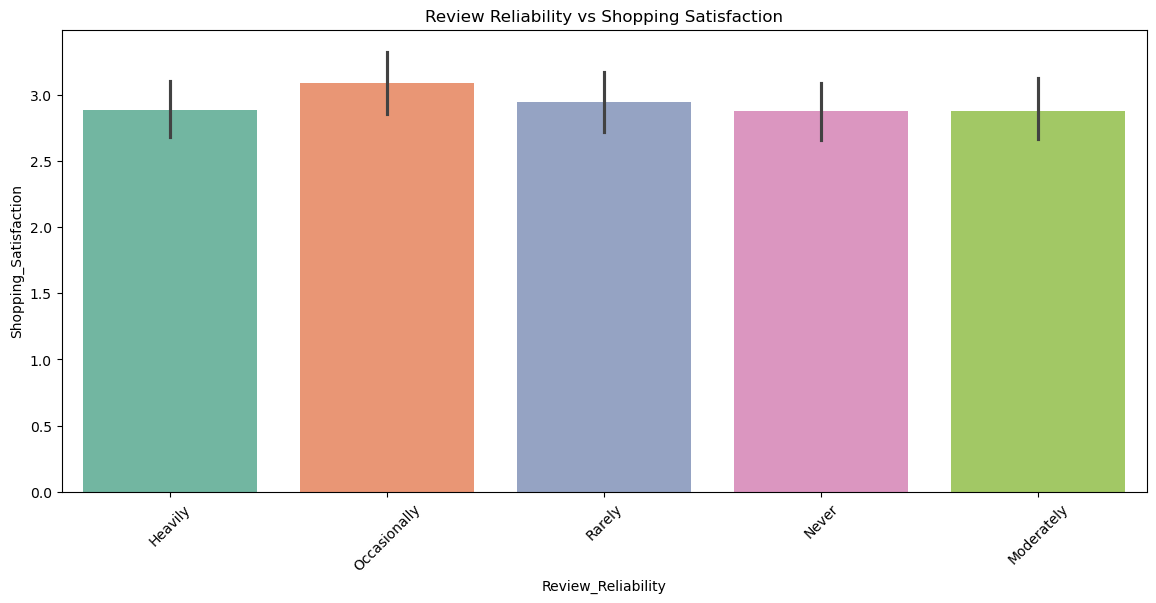

In [313]:
# Visualization Review Reliability vs Shopping Satisfaction
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Review_Reliability', y='Shopping_Satisfaction', palette='Set2', hue = 'Review_Reliability')
plt.title('Review Reliability vs Shopping Satisfaction')
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Review Helpfulness vs Rating Accuracy')

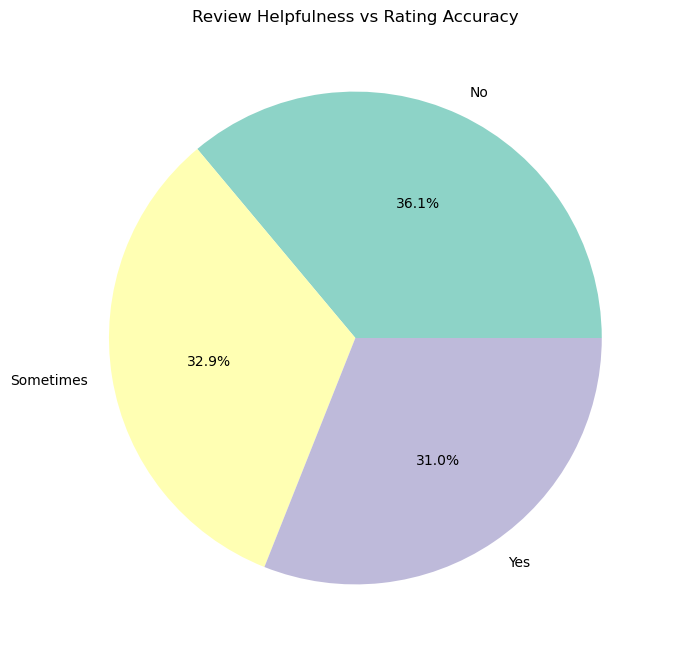

In [314]:
# 1. Group the data so each category has one total value
pie_data = df.groupby('Review_Helpfulness')['Rating_Accuracy'].sum()

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set3', len(pie_data))

# 3. Create the pie chart
plt.pie(pie_data, 
        labels=pie_data.index, 
        autopct='%1.1f%%', 
        colors=colors)

plt.title('Review Helpfulness vs Rating Accuracy')


While review trust doesn't change shopping satisfaction, unhelpful reviews cause a minor split in how much people trust the accuracy of product ratings.


Identify trends in how often customers engage with or trust personalized 
recommendations. 

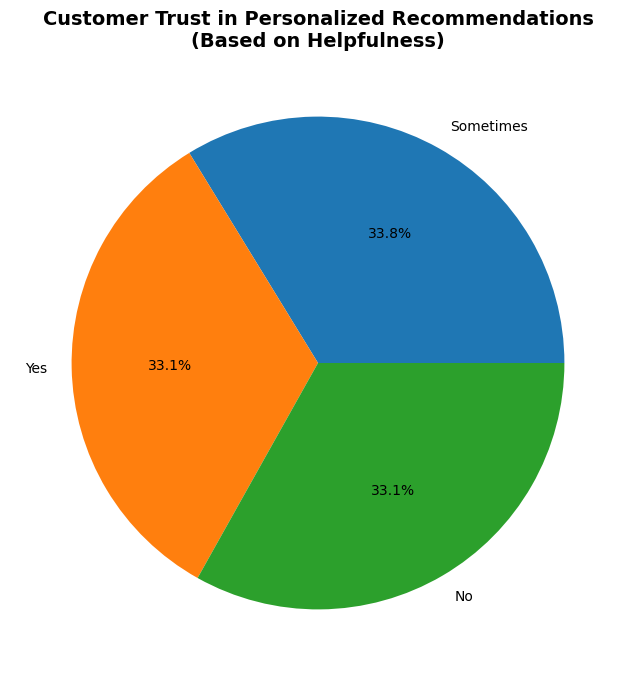

In [315]:
# Count the occurrences of 'Yes', 'No', and 'Sometimes'
trust_counts = df['Recommendation_Helpfulness'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    trust_counts, 
    labels=trust_counts.index, 
    autopct='%1.1f%%'
)

# Add a descriptive title
plt.title('Customer Trust in Personalized Recommendations\n(Based on Helpfulness)', fontsize=14, fontweight='bold')
plt.show()


In [316]:
all_mentions = []
# Loop through every row in the Purchase_Categories column
for response in df['Purchase_Categories']:
# Split the response into a list of individual categories using the semicolon
    categories = response.split(';')
    
# For each individual category, add it to our empty list
    for item in categories:
        all_mentions.append(item)
# 4. Count the occurrences of each Purchase Category
category_counts = Counter(all_mentions)
category_counts = pd.Series(category_counts).sort_values(ascending=False)
category_counts

Beauty and Personal Care      426
Clothing and Fashion          424
Home and Kitchen              406
Groceries and Gourmet Food    403
others                        384
dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_22140\1916800822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.values, x=category_counts.index, palette="viridis")


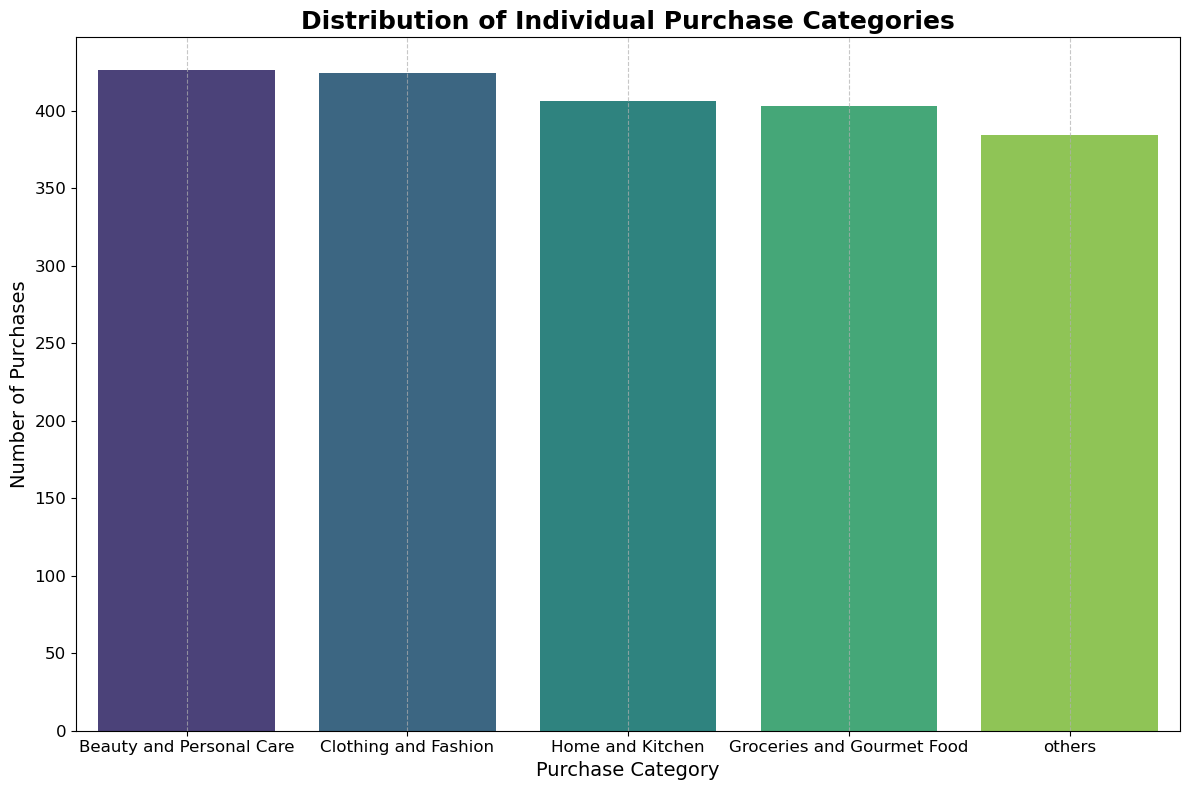

In [317]:
plt.figure(figsize=(12, 8))
sns.barplot(y=category_counts.values, x=category_counts.index, palette="viridis")

plt.title('Distribution of Individual Purchase Categories', fontsize=18, fontweight='bold')
plt.ylabel('Number of Purchases', fontsize=14)
plt.xlabel('Purchase Category', fontsize=14)
plt.yticks(fontsize=12 )
plt.xticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The distribution of purchases is remarkably balanced across categories, led by Beauty and Personal Care (426) and Clothing and Fashion (424). Even the lower-ranked Groceries and Home categories maintain high volume

C:\Users\USER\AppData\Local\Temp\ipykernel_22140\1112862724.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


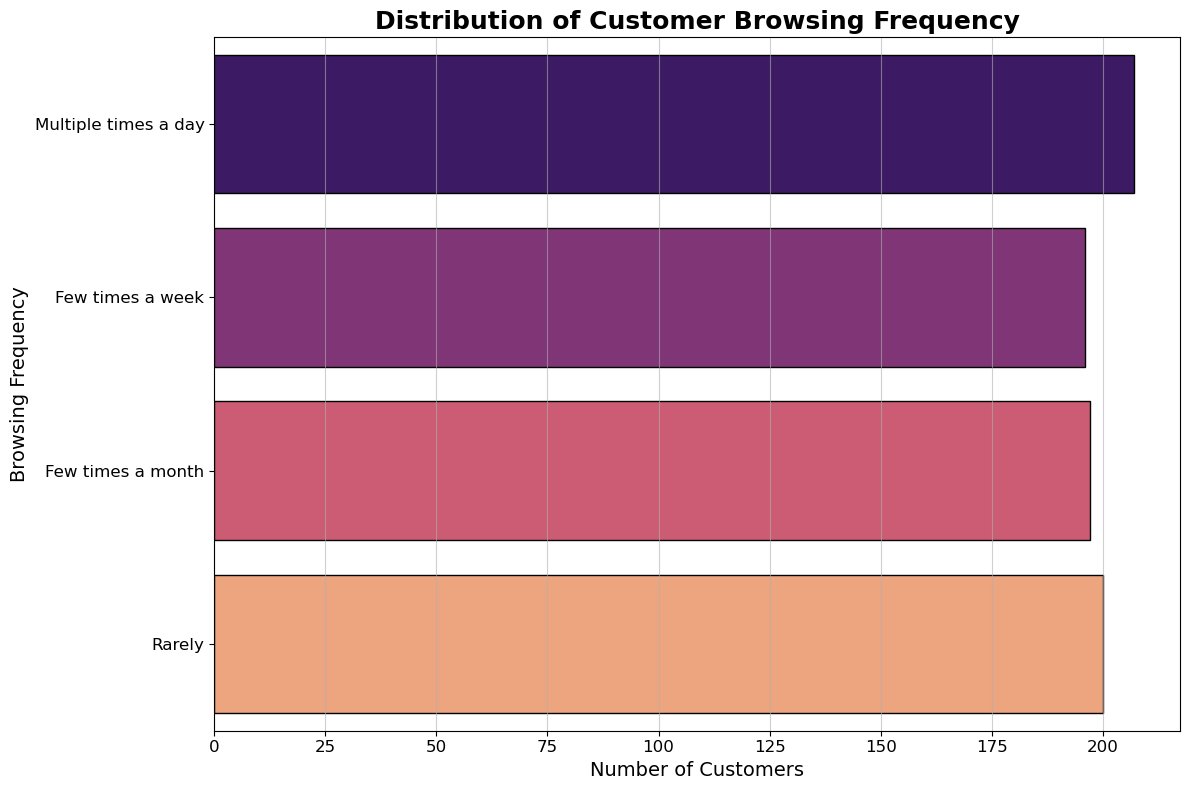

In [318]:
plt.figure(figsize=(12, 8))

# Define a logical order for the categories 
browsing_order = [
    'Multiple times a day', 
    'Few times a week', 
    'Few times a month', 
    'Rarely'
]

# Create the count plot
ax = sns.countplot(
    data=df, 
    y='Browsing_Frequency', 
    order=browsing_order, 
    palette="magma",
    edgecolor='black'
)

plt.title('Distribution of Customer Browsing Frequency', fontsize=18, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=14)
plt.ylabel('Browsing Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='x', alpha=0.6)
plt.tight_layout()
plt.show()


Customer browsing frequency is almost perfectly uniform across all groups, with "Multiple times a day" being the most common behavior. Each frequency level consistently captures approximately 200 customers, indicating a highly diverse range of engagement habits.


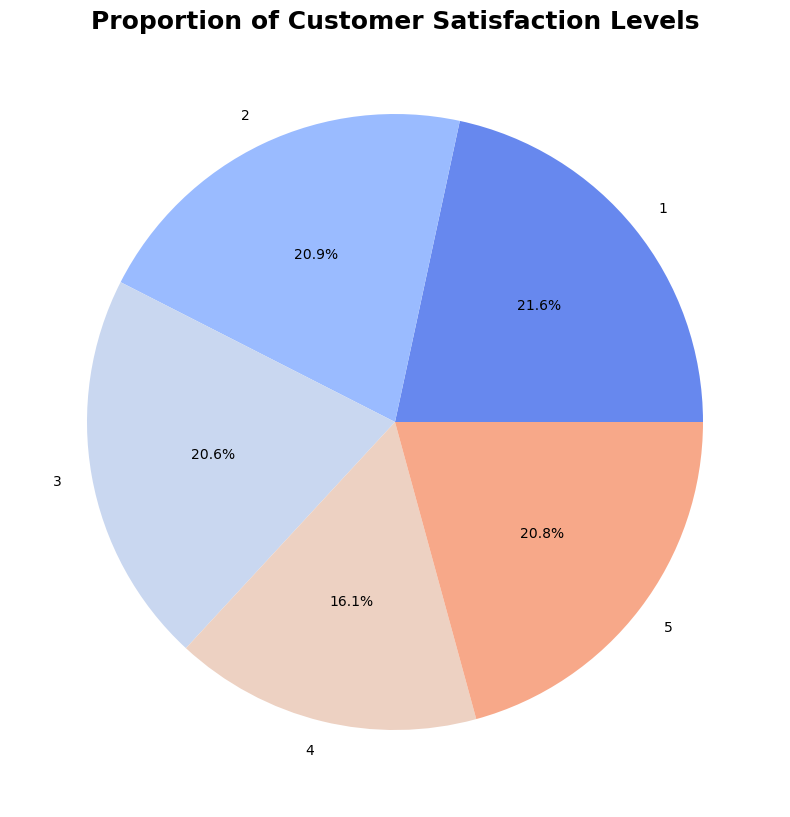

In [319]:
satisfaction_counts = df['Shopping_Satisfaction'].value_counts().sort_index()

plt.figure(figsize=(10, 10))

plt.pie(
    satisfaction_counts, 
    labels=satisfaction_counts.index, 
    colors=sns.color_palette("coolwarm"), # 1. Changed 'palette' to 'colors'
    autopct='%1.1f%%')

plt.title('Proportion of Customer Satisfaction Levels', fontsize=18, fontweight='bold')
plt.show()

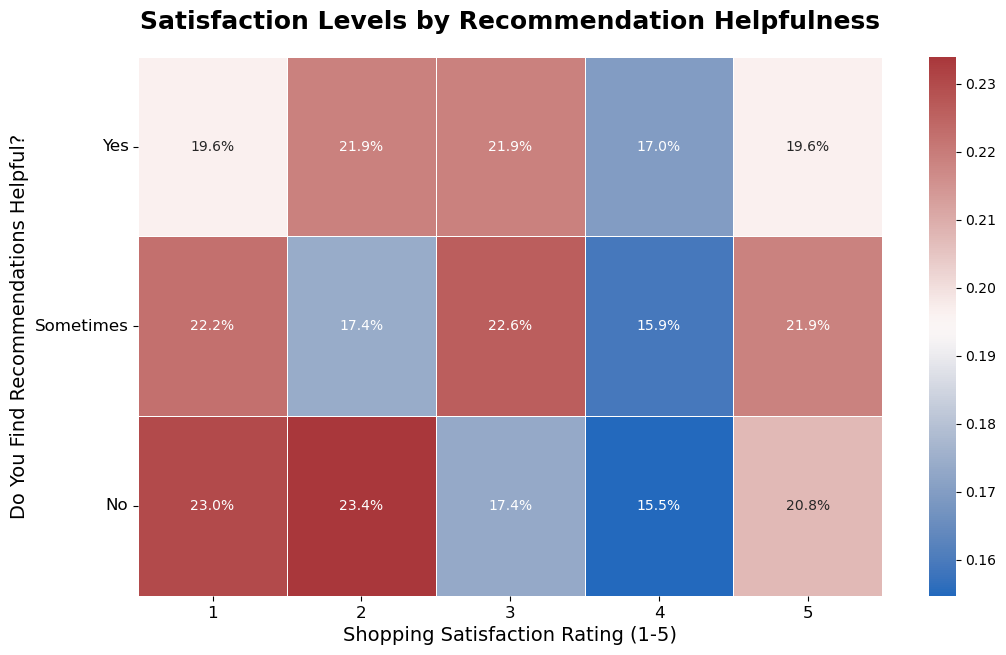

In [320]:
contingency_table = pd.crosstab(
    index=df['Recommendation_Helpfulness'], 
    columns=df['Shopping_Satisfaction'],
    normalize='index' 
)

# Reorder the index for a logical flow
contingency_table = contingency_table.reindex(['Yes', 'Sometimes', 'No'])

plt.figure(figsize=(12, 7))

sns.heatmap(
    contingency_table, 
    annot=True,          # Show the percentages in each cell
    fmt=".1%",           # Format the annotation as a percentage with one decimal place
    cmap="vlag",       # A nice, sequential color map (Yellow-Green-Blue)
    linewidths=.5,       # Add thin lines between cells  
)

# --- Add Title and Styling ---
plt.title('Satisfaction Levels by Recommendation Helpfulness', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Shopping Satisfaction Rating (1-5)', fontsize=14)
plt.ylabel('Do You Find Recommendations Helpful?', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0) 

plt.show()

There is a notable correlation between unhelpful recommendations and low satisfaction, with 23.4% of customers who find recommendations unhelpful giving a low satisfaction rating of 2. In contrast, those who find recommendations helpful ("Yes") are more likely to report mid-to-high satisfaction, peaking at 21.9% for ratings 2 and 3.

In [342]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Prepare transactions
# Purchase_Categories contains items separated by ';'
transactions = df['Purchase_Categories'].dropna().apply(
    lambda x: [item.strip() for item in x.split(';') if item.strip()]
).tolist()

# Transaction Encoding 
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_te, min_support=0.1, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

result = rules[['antecedents', 'consequents', 'confidence', 'lift']].sort_values(by='lift', ascending=False)
    
print("Top 10 Purchase Category Recommendations")
display(result.head(10).reset_index())


Top 10 Purchase Category Recommendations


,index,antecedents,consequents,confidence,lift
0,43,"(others, Groceries and Gourmet Food)",(Clothing and Fashion),0.651934,1.230064
1,47,"(Home and Kitchen, others)",(Clothing and Fashion),0.609890,1.150736
2,42,"(Clothing and Fashion, Groceries and Gourmet F...",(others),0.533937,1.112368
3,44,(others),"(Clothing and Fashion, Groceries and Gourmet F...",0.307292,1.112368
4,40,"(Home and Kitchen, Groceries and Gourmet Food)",(Clothing and Fashion),0.585859,1.105394
5,24,"(Beauty and Personal Care, Home and Kitchen)",(Clothing and Fashion),0.575758,1.086335
6,45,"(Clothing and Fashion, Home and Kitchen)",(others),0.516279,1.075581
7,41,"(Clothing and Fashion, others)",(Groceries and Gourmet Food),0.541284,1.074510
8,12,(Clothing and Fashion),(others),0.514151,1.071148
9,13,(others),(Clothing and Fashion),0.567708,1.071148


Top Insight: Customers buying Groceries or Home items have a strong 65% probability of also purchasing Clothing.

Recommendation: It turns out Clothing is the ultimate add-on people buying Groceries or Home stuff end up grabbing clothes almost all of the time! Since these shoppers are already in a buying mood, we should definitely start recommending more Clothing and Fashion.  

### Actionable Strategy

* Cross-Sell: Leverage the 65% Grocery-to-Clothing link
* Convert: Move the 196 Occasional Shoppers into the loyal Frequent Buyer group.
* Refine: Fix the recommendation friction to boost our overall satisfaction score.
* Display estimated shipping fees on product pages or in the cart summary rather than waiting until the final checkout step.

### Summary Video

https://drive.google.com/file/d/1X1FcLhnjKu3MpdkAlnvDzqm_z-apMNru/view?usp=sharing